<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 50px 40px; border-radius: 16px; font-family: 'Georgia', serif; margin-bottom: 10px; text-align: left;">

  <p style="color: #e94560; font-size: 13px; letter-spacing: 3px; text-transform: uppercase; margin-bottom: 10px;">
    Natural Language Processing · Machine Learning
  </p>

  <h1 style="color: #ffffff; font-size: 40px; font-weight: 700; margin: 0 0 16px 0; line-height: 1.2;">
    Fake News Detection
  </h1>

  <h2 style="color: #a8dadc; font-size: 22px; font-weight: 400; margin: 0 0 24px 0;">
    NLP-Based News Classification System
  </h2>

  <hr style="border: 1px solid #e94560; width: 120px; margin: 20px 0;">

  <p style="color: #c9d6df; font-size: 14px; margin: 0;">
    Dataset:
    <a href="https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset" style="color:#e94560;">
      Fake and Real News Dataset
    </a>
    &nbsp;|&nbsp; Kaggle Notebook &nbsp;|&nbsp; 2026
  </p>

</div>



## 📋 Table of Contents

1. [Introduction & Problem Statement](#1-introduction)
2. [Dataset Description](#2-dataset)
3. [Import Libraries](#3-imports)
4. [Load & Merge Dataset](#4-load-data)
5. [Exploratory Data Analysis](#5-eda)
6. [Data Quality Checks](#6-quality)
7. [Text Cleaning & Preprocessing](#7-preprocessing)
8. [Text Statistics](#8-statistics)
9. [Word Clouds](#9-wordclouds)
10. [Most Frequent Words](#10-frequent-words)
11. [Bigram & Trigram Analysis](#11-ngrams)
12. [TF-IDF Feature Extraction](#12-tfidf)
13. [Train-Test Split](#13-split)
14. [Baseline Model](#14-baseline)
15. [Multi-Model Training & Comparison](#15-models)
16. [Hyperparameter Tuning](#16-tuning)
17. [Cross-Validation](#17-crossval)
18. [Model Evaluation](#18-evaluation)
19. [Feature Importance & Top Predictive Terms](#19-features)
20. [Error Analysis](#20-errors)
21. [Select Best Model](#21-best-model)
22. [Save Artifacts](#22-save)
23. [Custom Prediction Function](#23-predict)
24. [Conclusions](#24-conclusions)
25. [Limitations](#25-limitations)
26. [Future Work](#26-future)



<a id='1-introduction'></a>
## 1. Introduction & Problem Statement

### 🎯 Overview
The proliferation of misinformation and fake news has emerged as one of the most critical challenges of the digital information age. Fabricated stories spread at exponential speed across social media platforms, influencing public opinion, elections, and even public health outcomes.

This project develops a **production-grade, end-to-end NLP pipeline** to automatically classify news articles as *Fake* or *Real* using classical machine learning models augmented by advanced text preprocessing and TF-IDF feature engineering.

### 🔬 Objectives
- Build a reproducible, modular preprocessing pipeline for raw news text
- Engineer discriminative TF-IDF features capturing lexical and stylistic signals
- Train and rigorously compare multiple supervised classifiers
- Perform hyperparameter optimization and cross-validation
- Produce a deployment-ready artifact with a custom inference function

### 🏭 Real-World Applications
| Domain | Application |
|---|---|
| Social Media Platforms | Automated content moderation and flagging |
| News Aggregators | Credibility scoring before content promotion |
| Journalism | Fact-checking assistance tools |
| Government & Policy | Monitoring information warfare |
| Education | Media literacy training systems |

### ✅ Expected Outcomes
- Classification accuracy **≥ 98%** on held-out test data
- Interpretable feature analysis revealing linguistic markers of fake news
- Deployable model artifact with a clean inference API

<a id='2-dataset'></a>
## 2. Dataset Description

**Source:** [Clément Bisaillon  Kaggle](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset)

The dataset consists of two CSV files:

| File | Label | Articles |
|---|---|---|
| `Fake.csv` | 0  Fake | ~23,481 |
| `True.csv` | 1  Real | ~21,417 |

**Columns:**
- `title`  Headline of the article
- `text`  Full body text
- `subject`  News category (e.g., politics, world news)
- `date`  Publication date

> **Note:** The dataset is well-balanced (~52% Fake / ~48% Real), minimizing the need for class-imbalance mitigation techniques.

<a id='3-imports'></a>
## 3. Import Required Libraries

In [1]:
# Core
import os, re, warnings, joblib, string
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams
from collections import Counter

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Setup
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# Download required NLTK assets
for pkg in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

# Global style
PALETTE   = {'Fake': '#e94560', 'Real': '#0f9b8e'}
BG_COLOR  = '#f8f9fc'
plt.rcParams.update({
    'figure.facecolor' : BG_COLOR,
    'axes.facecolor'   : BG_COLOR,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 12,
})

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


<a id='4-load-data'></a>
## 4. Load & Merge Dataset

In [2]:
# Load raw CSVs 
fake_df = pd.read_csv('/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv')
real_df = pd.read_csv('/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv')

fake_df['label'] = 0   # Fake
real_df['label'] = 1   # Real
fake_df['label_name'] = 'Fake'
real_df['label_name'] = 'Real'

# Merge & shuffle
df = pd.concat([fake_df, real_df], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Combine title + text for richer features
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

print(f"Dataset shape : {df.shape}")
print(f"Fake articles : {(df.label == 0).sum():,}")
print(f"Real articles : {(df.label == 1).sum():,}")
df.head(3)

Dataset shape : (44898, 7)
Fake articles : 23,481
Real articles : 21,417


,title,text,subject,date,label,label_name,content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Fake,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Real,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Real,Puerto Rico expects U.S. to lift Jones Act shi...


<a id='5-eda'></a>
## 5. Exploratory Data Analysis (EDA)

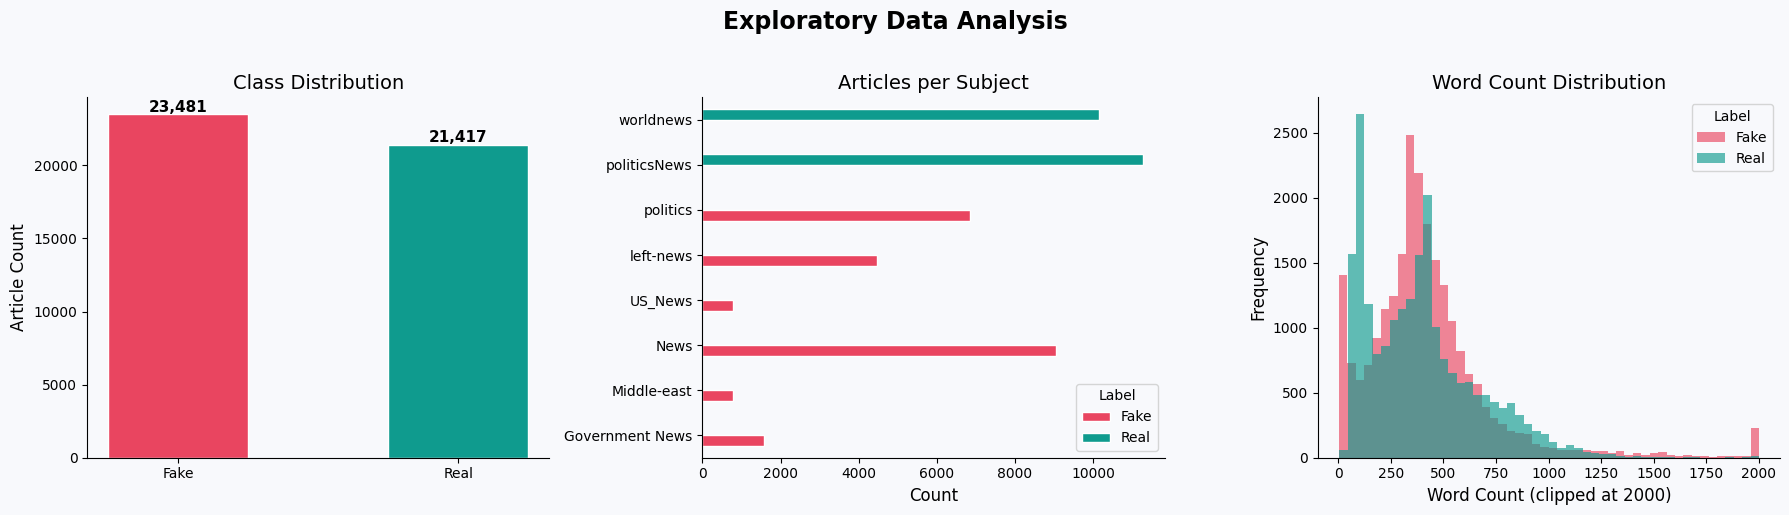

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=17, fontweight='bold', y=1.02)

# 1. Class Distribution
counts = df['label_name'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE['Fake'], PALETTE['Real']], width=0.5, edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Article Count')
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 200,
                 f'{b.get_height():,}', ha='center', fontsize=11, fontweight='bold')

# 2. Articles per Subject
subj = df.groupby(['subject', 'label_name']).size().unstack(fill_value=0)
subj.plot(kind='barh', ax=axes[1], color=[PALETTE['Fake'], PALETTE['Real']], edgecolor='white')
axes[1].set_title('Articles per Subject')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')
axes[1].legend(title='Label')

# 3. Article Length Distribution
df['text_length'] = df['content'].str.split().str.len()
for label, color in PALETTE.items():
    subset = df[df['label_name'] == label]['text_length']
    axes[2].hist(subset.clip(upper=2000), bins=50, alpha=0.65, color=color, label=label)
axes[2].set_title('Word Count Distribution')
axes[2].set_xlabel('Word Count (clipped at 2000)')
axes[2].set_ylabel('Frequency')
axes[2].legend(title='Label')

plt.tight_layout()
plt.show()

In [4]:
# Summary statistics by label
df.groupby('label_name')['text_length'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Fake,23481.0,437.9,408.6,2.0,254.0,378.0,521.0,8148.0
Real,21417.0,395.6,273.9,4.0,159.0,369.0,534.0,5181.0


<a id='6-quality'></a>
## 6. Data Quality Checks

In [5]:
print("=" * 45)
print(" DATA QUALITY REPORT")
print("=" * 45)

# Missing values
missing = df[['title', 'text', 'content']].isnull().sum()
print("\n📌 Missing Values:")
print(missing.to_string())

# Duplicates
dup_count = df['content'].duplicated().sum()
print(f"\n📌 Duplicate articles : {dup_count}")

# Empty content
empty = (df['content'].str.strip() == '').sum()
print(f"📌 Empty content rows  : {empty}")

# Drop duplicates and empty
df.drop_duplicates(subset='content', inplace=True)
df = df[df['content'].str.strip() != ''].reset_index(drop=True)

print(f"\n✅ Clean dataset shape : {df.shape}")

 DATA QUALITY REPORT

📌 Missing Values:
title      0
text       0
content    0

📌 Duplicate articles : 5793
📌 Empty content rows  : 0

✅ Clean dataset shape : (39105, 8)


<a id='7-preprocessing'></a>
## 7. Text Cleaning & Preprocessing

A modular preprocessing pipeline is constructed, applying each transformation in sequence:

| Step | Transformation |
|---|---|
| 1 | Lowercase conversion |
| 2 | Remove URLs & HTML tags |
| 3 | Remove punctuation & numbers |
| 4 | Tokenization |
| 5 | Stopword removal |
| 6 | Lemmatization |

In [6]:
lemmatizer   = WordNetLemmatizer()
STOP_WORDS   = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Full preprocessing pipeline returning a clean string."""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)       # URLs
    text = re.sub(r'<[^>]+>', ' ', text)                       # HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)                     # punctuation & numbers
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing articles … (this may take ~60 s on Kaggle CPUs)")
df['clean_content'] = df['content'].apply(clean_text)
print(f"✅ Done.  Sample output:\n{df['clean_content'].iloc[0][:200]}")

Preprocessing articles … (this may take ~60 s on Kaggle CPUs)
✅ Done.  Sample output:
ben stein call circuit court committed coup tat constitution century wire say ben stein reputable professor pepperdine university also hollywood fame appearing show film ferris bueller day made provoc


<a id='8-statistics'></a>
## 8. Text Statistics

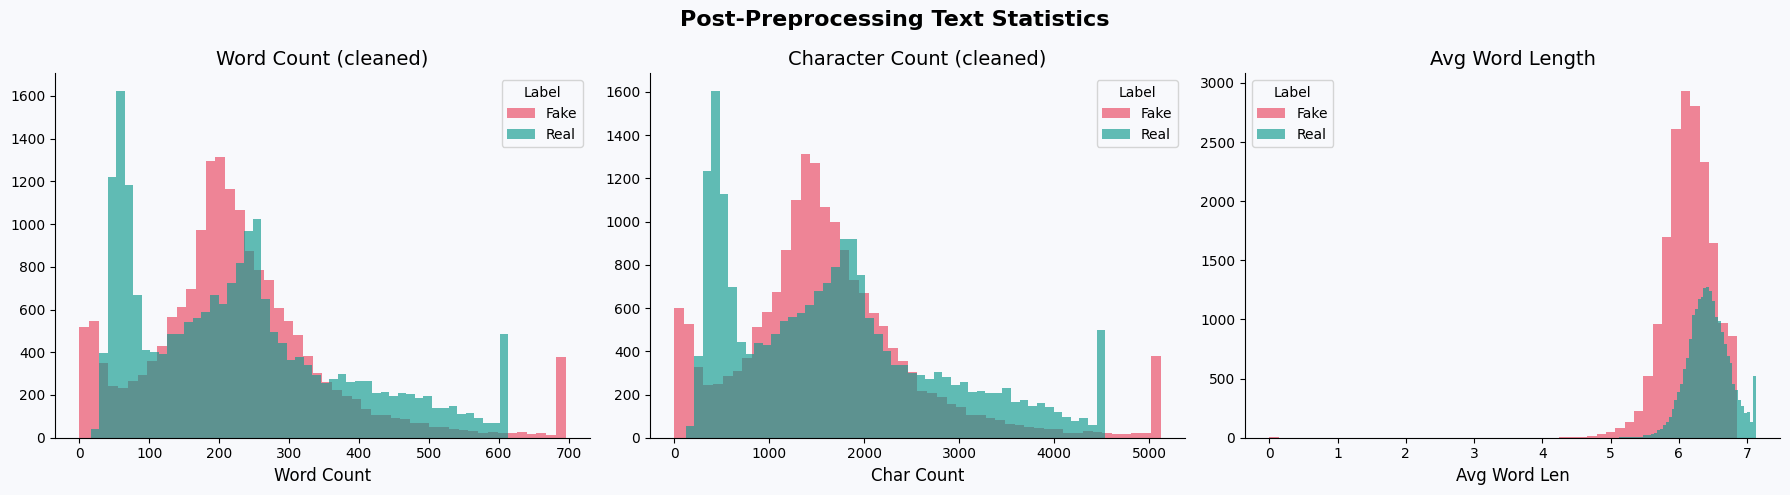

,word_count,char_count,avg_word_len
label_name,,,
Fake,236.84,1708.27,6.15
Real,232.59,1725.00,6.43


In [7]:
df['word_count'] = df['clean_content'].str.split().str.len()
df['char_count'] = df['clean_content'].str.len()
df['avg_word_len'] = df['clean_content'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Post-Preprocessing Text Statistics', fontsize=16, fontweight='bold')

metrics = ['word_count', 'char_count', 'avg_word_len']
titles  = ['Word Count (cleaned)', 'Character Count (cleaned)', 'Avg Word Length']

for ax, metric, title in zip(axes, metrics, titles):
    for label, color in PALETTE.items():
        vals = df[df['label_name'] == label][metric]
        ax.hist(vals.clip(upper=vals.quantile(0.98)), bins=50,
                alpha=0.65, color=color, label=label)
    ax.set_title(title)
    ax.set_xlabel(metric.replace('_', ' ').title())
    ax.legend(title='Label')

plt.tight_layout()
plt.show()

# Summary table
df.groupby('label_name')[metrics].mean().round(2)

<a id='9-wordclouds'></a>
## 9. Word Clouds for Fake and Real News

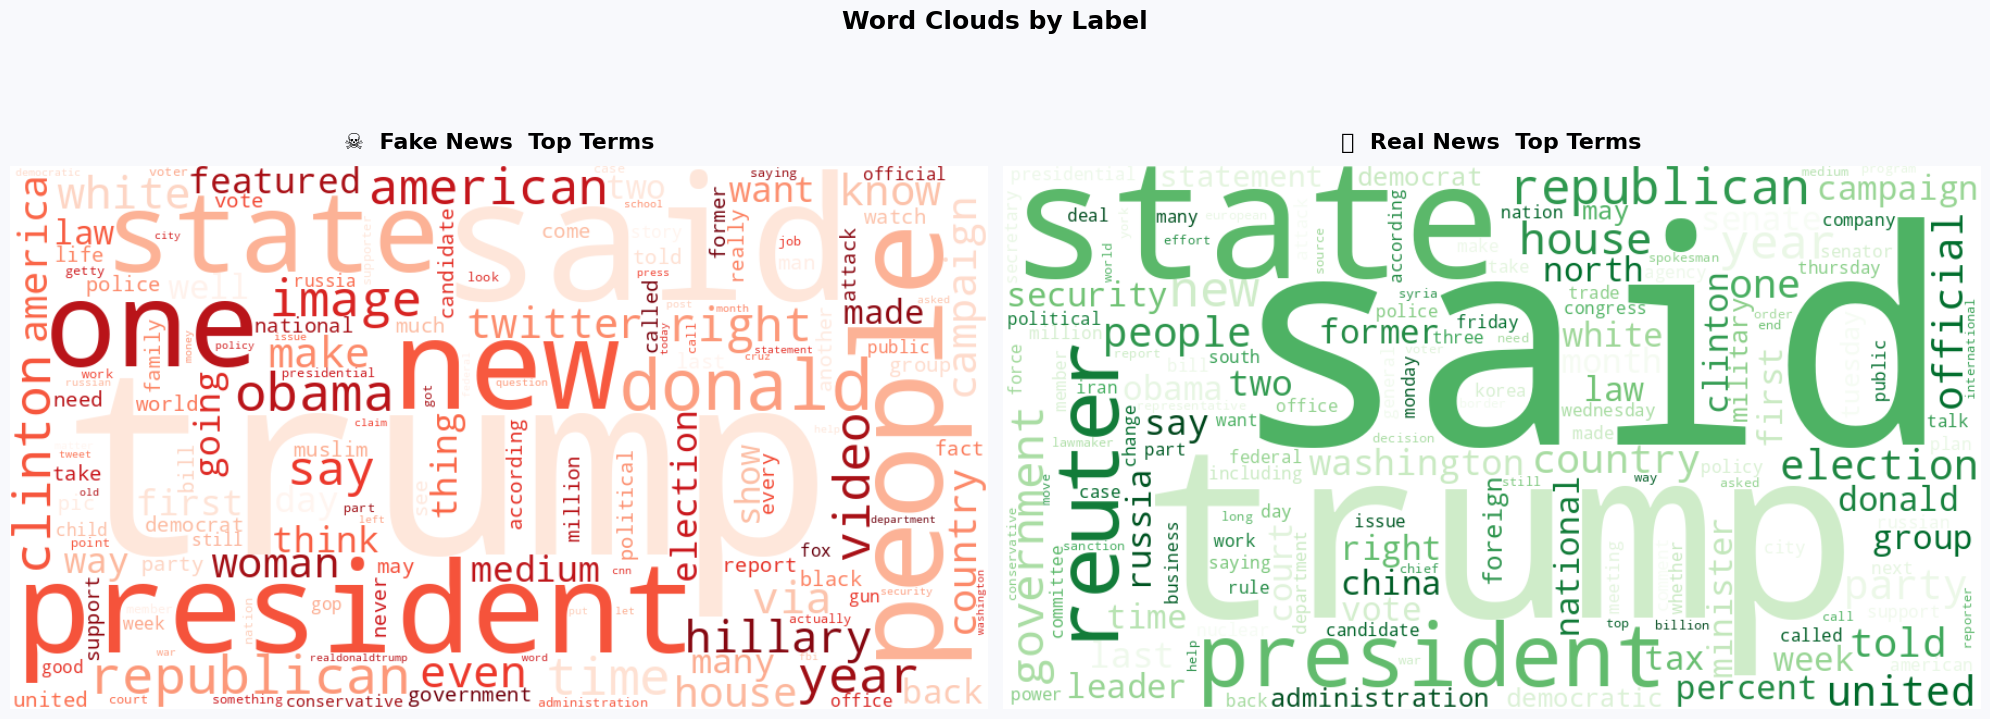

In [8]:
def generate_wordcloud(text_series, colormap, title, ax):
    corpus = ' '.join(text_series)
    wc = WordCloud(
        width=900, height=500, background_color='white',
        colormap=colormap, max_words=150, collocations=False,
        random_state=SEED
    ).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=12)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
generate_wordcloud(df[df['label_name'] == 'Fake']['clean_content'], 'Reds',   '☠️  Fake News  Top Terms', axes[0])
generate_wordcloud(df[df['label_name'] == 'Real']['clean_content'], 'Greens', '✅  Real News  Top Terms', axes[1])
plt.suptitle('Word Clouds by Label', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<a id='10-frequent-words'></a>
## 10. Most Frequent Words

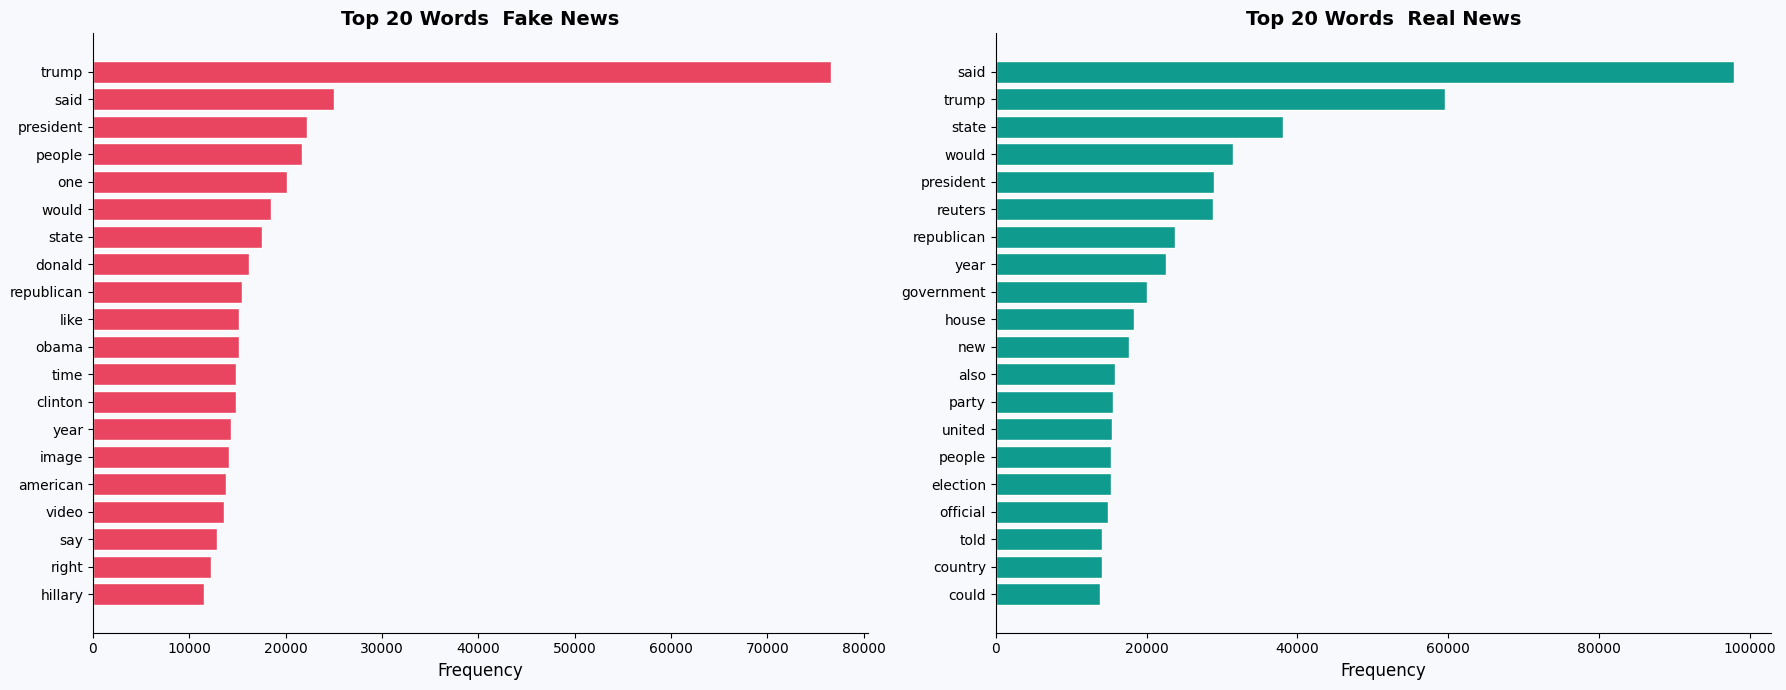

In [9]:
def top_n_words(text_series, n=20):
    all_words = ' '.join(text_series).split()
    return pd.DataFrame(Counter(all_words).most_common(n), columns=['Word', 'Count'])

fake_top = top_n_words(df[df['label_name'] == 'Fake']['clean_content'])
real_top = top_n_words(df[df['label_name'] == 'Real']['clean_content'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, top_df, label, color in zip(
    axes, [fake_top, real_top], ['Fake', 'Real'], [PALETTE['Fake'], PALETTE['Real']]
):
    ax.barh(top_df['Word'][::-1], top_df['Count'][::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 20 Words  {label} News', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

<a id='11-ngrams'></a>
## 11. Bigram & Trigram Analysis

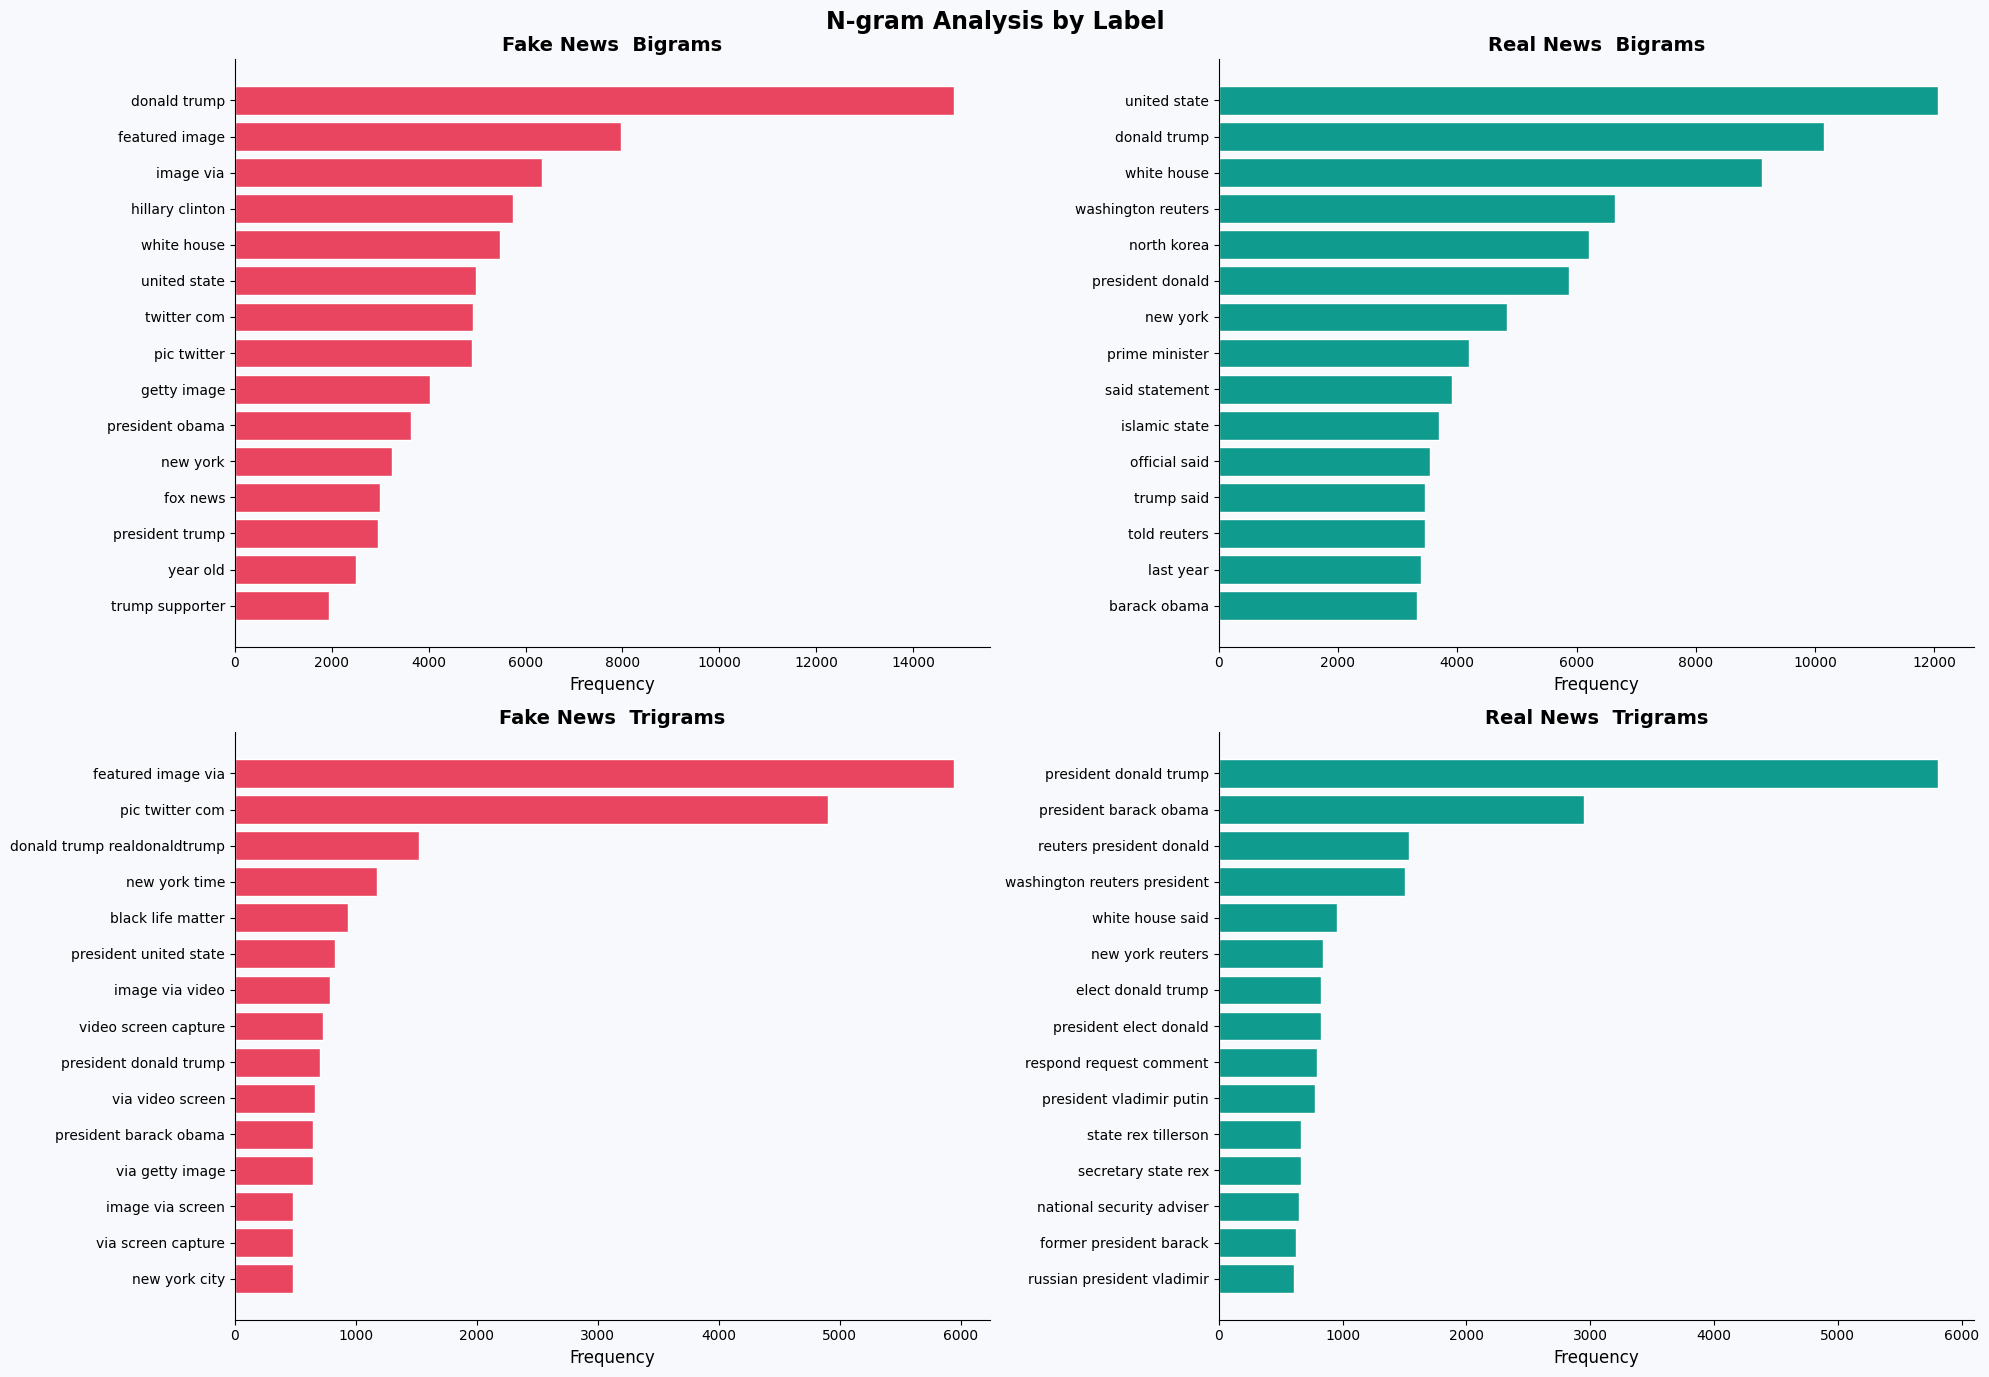

In [10]:
def top_ngrams(text_series, n=2, top_k=15):
    all_tokens = ' '.join(text_series).split()
    ng = Counter(ngrams(all_tokens, n))
    top = ng.most_common(top_k)
    return pd.DataFrame([(' '.join(k), v) for k, v in top], columns=['ngram', 'count'])

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('N-gram Analysis by Label', fontsize=17, fontweight='bold')

configs = [
    (0, 0, 'Fake', 2, PALETTE['Fake'], 'Fake News  Bigrams'),
    (0, 1, 'Real', 2, PALETTE['Real'], 'Real News  Bigrams'),
    (1, 0, 'Fake', 3, PALETTE['Fake'], 'Fake News  Trigrams'),
    (1, 1, 'Real', 3, PALETTE['Real'], 'Real News  Trigrams'),
]

for row, col, label, n, color, title in configs:
    ng_df = top_ngrams(df[df['label_name'] == label]['clean_content'], n=n)
    axes[row, col].barh(ng_df['ngram'][::-1], ng_df['count'][::-1], color=color, edgecolor='white')
    axes[row, col].set_title(title, fontweight='bold')
    axes[row, col].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

<a id='12-tfidf'></a>
## 12. TF-IDF Feature Extraction

TF-IDF (Term FrequencyInverse Document Frequency) transforms text into a numerical matrix that captures the relative importance of each term within a document with respect to the entire corpus. We retain up to **100,000 unigram and bigram features**, removing extremely rare or overly common terms.

In [11]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=100_000,
    sublinear_tf=True,
    min_df=3,
    max_df=0.90,
)

X = tfidf.fit_transform(df['clean_content'])
y = df['label'].values

print(f"Feature matrix shape : {X.shape}")
print(f"Vocabulary size      : {len(tfidf.vocabulary_):,}")
print(f"Matrix sparsity      : {1 - X.nnz / (X.shape[0]*X.shape[1]):.4%}")

Feature matrix shape : (39105, 100000)
Vocabulary size      : 100,000
Matrix sparsity      : 99.7737%


<a id='13-split'></a>
## 13. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")
print(f"Class balance (train) → Fake: {(y_train==0).sum():,} | Real: {(y_train==1).sum():,}")

Training samples : 31,284
Test samples     : 7,821
Class balance (train) → Fake: 14,326 | Real: 16,958


<a id='14-baseline'></a>
## 14. Baseline Model

A **Stratified Dummy Classifier** provides the baseline performance ceiling that any meaningful model must exceed.

In [13]:
dummy = DummyClassifier(strategy='stratified', random_state=SEED)
dummy.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, dummy.predict(X_test))
print(f"Baseline accuracy (Stratified Dummy) : {baseline_acc:.4f}")

Baseline accuracy (Stratified Dummy) : 0.4981


<a id='15-models'></a>
## 15. Train & Compare Multiple Models

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED, C=1.0, solver='lbfgs'),
    'Multinomial NB'     : MultinomialNB(alpha=0.1),
    'LinearSVC'          : LinearSVC(max_iter=2000, random_state=SEED, C=1.0),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    # ROC-AUC requires probability or decision scores
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_score),
    })
    print(f"{name:<25} Acc={accuracy_score(y_test,y_pred):.4f}  F1={f1_score(y_test,y_pred):.4f}")

results_df = pd.DataFrame(results).set_index('Model').sort_values('F1-Score', ascending=False)
print("\n", results_df.round(4))

Logistic Regression       Acc=0.9891  F1=0.9900
Multinomial NB            Acc=0.9611  F1=0.9639
LinearSVC                 Acc=0.9955  F1=0.9959
Random Forest             Acc=0.9912  F1=0.9919

                      Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
LinearSVC              0.9955     0.9939  0.9979    0.9959   0.9997
Random Forest          0.9912     0.9883  0.9955    0.9919   0.9995
Logistic Regression    0.9891     0.9848  0.9953    0.9900   0.9989
Multinomial NB         0.9611     0.9701  0.9578    0.9639   0.9918


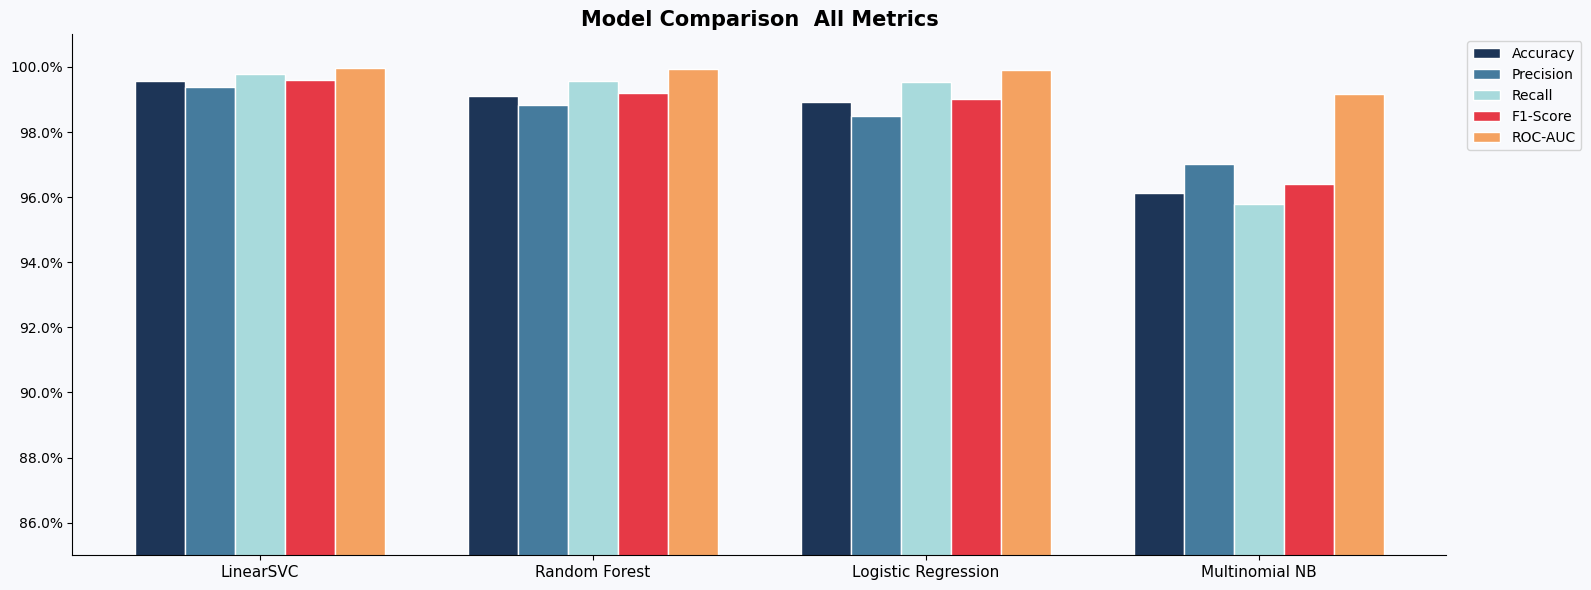

In [15]:
# Visual model comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15
colors = ['#1d3557', '#457b9d', '#a8dadc', '#e63946', '#f4a261']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, edgecolor='white')

ax.set_xticks(x + width*2)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylim(0.85, 1.01)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Model Comparison  All Metrics', fontsize=15, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

<a id='16-tuning'></a>
## 16. Hyperparameter Tuning (GridSearchCV)

We tune the top-performing model (Logistic Regression) using a 5-fold stratified grid search.

In [16]:
param_grid = {'C': [0.01, 0.1, 1, 5, 10], 'solver': ['lbfgs', 'saga']}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=SEED),
    param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Best parameters : {'C': 10, 'solver': 'saga'}
Best CV F1-Score: 0.9942


<a id='17-crossval'></a>
## 17. Cross-Validation

5-Fold CV F1-Scores : [0.9931 0.9943 0.9947 0.9946 0.9943]
Mean ± Std          : 0.9942 ± 0.0006


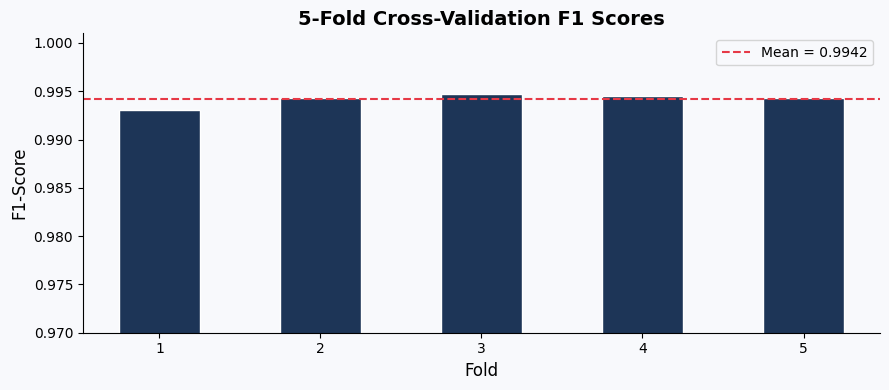

In [17]:
best_lr = grid_search.best_estimator_

cv_scores = cross_val_score(best_lr, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
print(f"5-Fold CV F1-Scores : {cv_scores.round(4)}")
print(f"Mean ± Std          : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 6), cv_scores, color='#1d3557', edgecolor='white', width=0.5)
ax.axhline(cv_scores.mean(), color='#e63946', linestyle='--', linewidth=1.5, label=f'Mean = {cv_scores.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('F1-Score')
ax.set_title('5-Fold Cross-Validation F1 Scores', fontweight='bold')
ax.legend()
ax.set_ylim(0.97, 1.001)
plt.tight_layout()
plt.show()

<a id='18-evaluation'></a>
## 18. Model Evaluation

In [18]:
y_pred_best  = best_lr.predict(X_test)
y_prob_best  = best_lr.predict_proba(X_test)[:, 1]

print("=" * 50)
print(" FINAL MODEL EVALUATION REPORT")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Fake', 'Real']))

 FINAL MODEL EVALUATION REPORT
Accuracy  : 0.9939
Precision : 0.9916
Recall    : 0.9972
F1-Score  : 0.9944
ROC-AUC   : 0.9995

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      3582
        Real       0.99      1.00      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



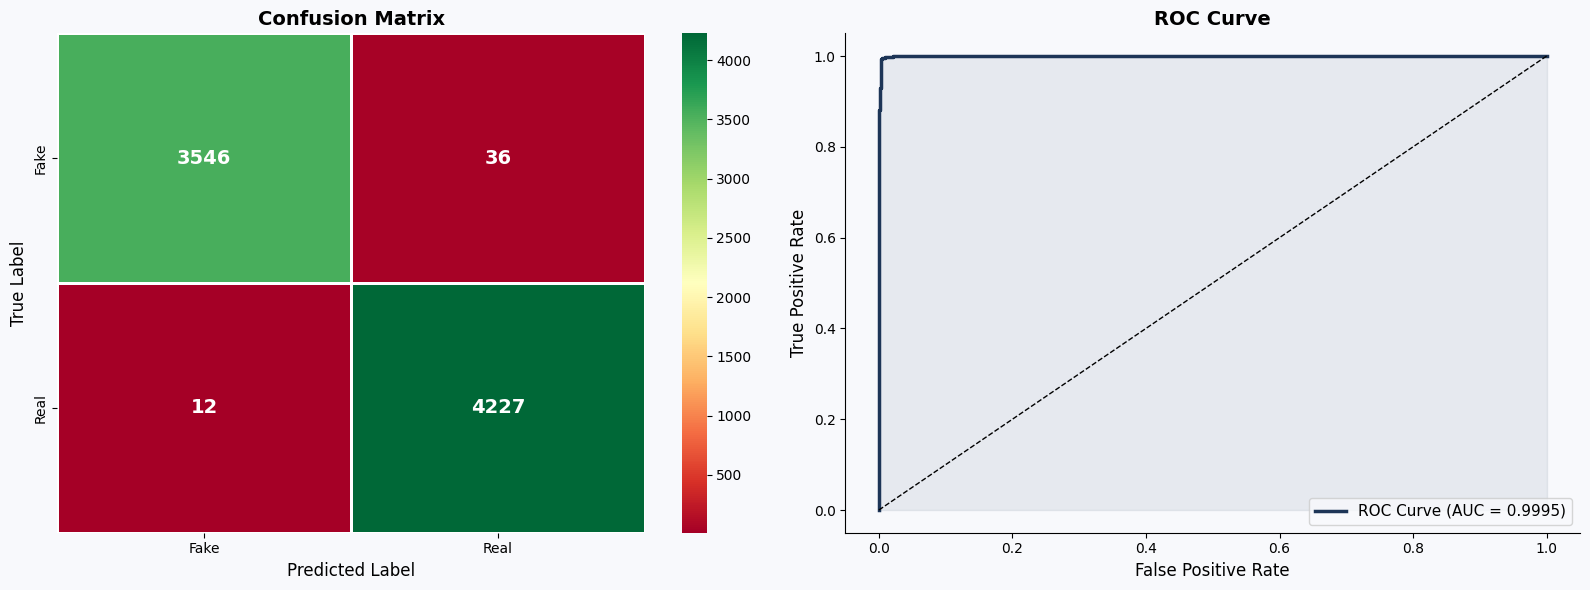

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=axes[0],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
            linewidths=1, linecolor='white', annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_val = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='#1d3557', lw=2.5, label=f'ROC Curve (AUC = {auc_val:.4f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#1d3557')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=14)
axes[1].legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

<a id='19-features'></a>
## 19. Feature Importance & Top Predictive Terms

Logistic Regression coefficients directly represent each term's contribution to classifying an article as Fake (negative coefficient) or Real (positive coefficient).

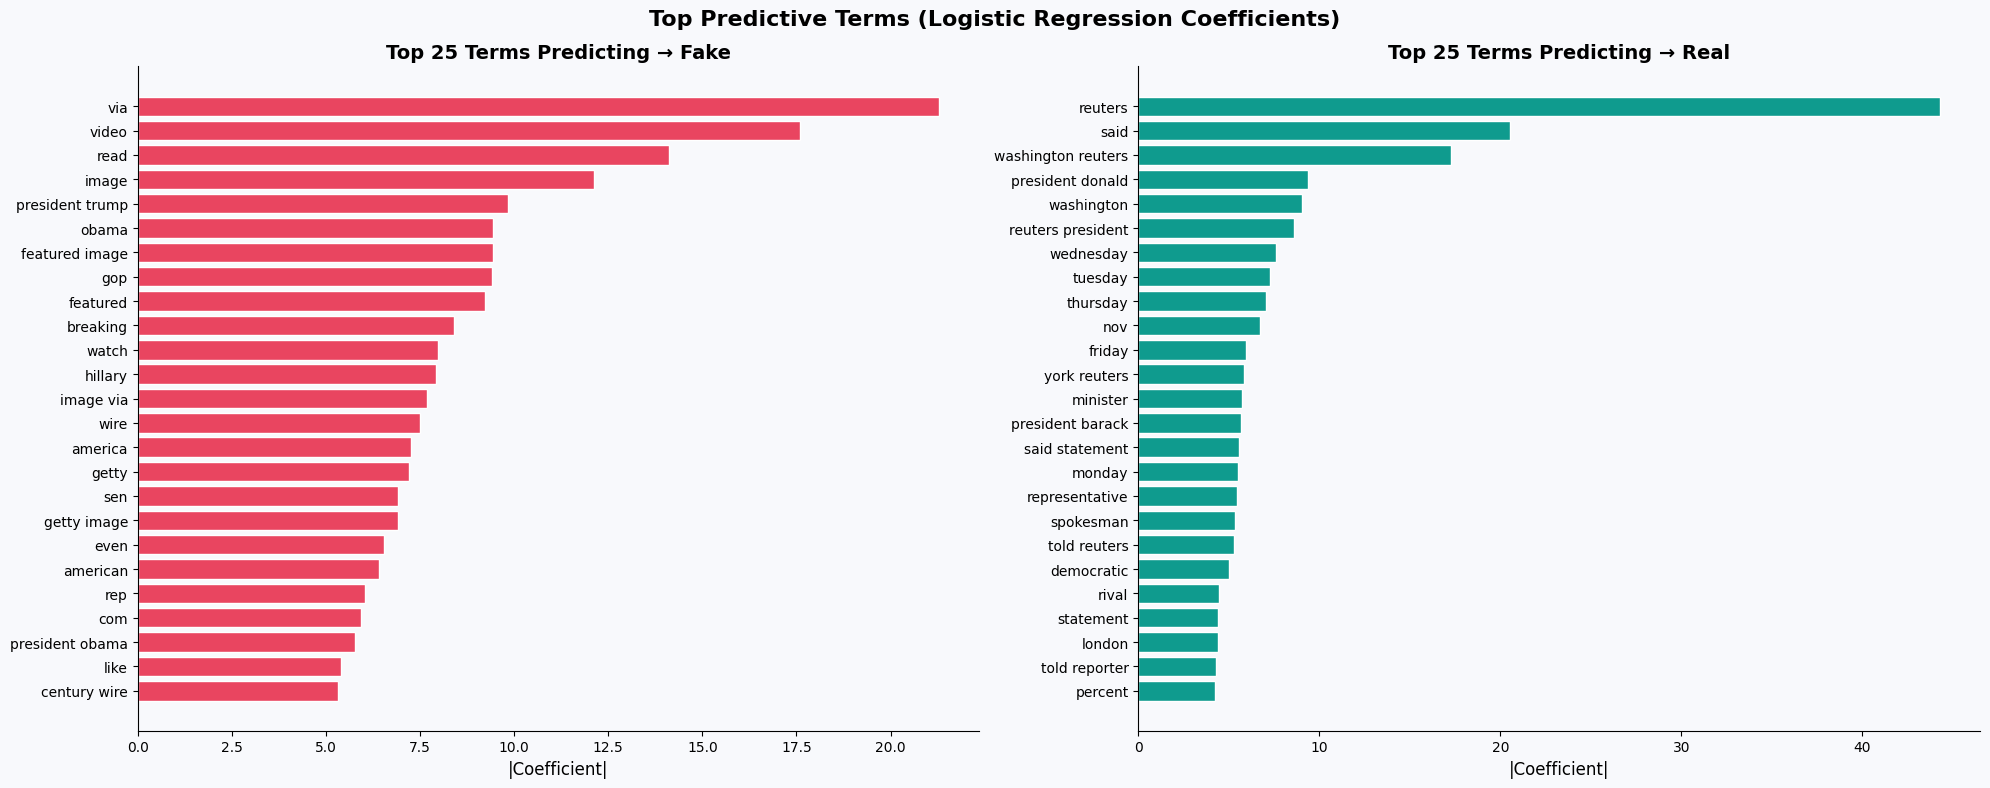

In [20]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = best_lr.coef_[0]
TOP_K = 25

top_fake_idx = np.argsort(coefs)[:TOP_K]         # most negative → Fake
top_real_idx = np.argsort(coefs)[-TOP_K:][::-1]  # most positive → Real

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Top Predictive Terms (Logistic Regression Coefficients)', fontsize=16, fontweight='bold')

for ax, idx, label, color in [
    (axes[0], top_fake_idx, 'Fake', PALETTE['Fake']),
    (axes[1], top_real_idx, 'Real', PALETTE['Real'])
]:
    vals = np.abs(coefs[idx])
    ax.barh(feature_names[idx][::-1], vals[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top {TOP_K} Terms Predicting → {label}', fontweight='bold')
    ax.set_xlabel('|Coefficient|')

plt.tight_layout()
plt.show()

<a id='20-errors'></a>
## 20. Error Analysis

Understanding where the model fails is as important as measuring where it succeeds.

Total misclassified : 48 / 7821 (0.61%)


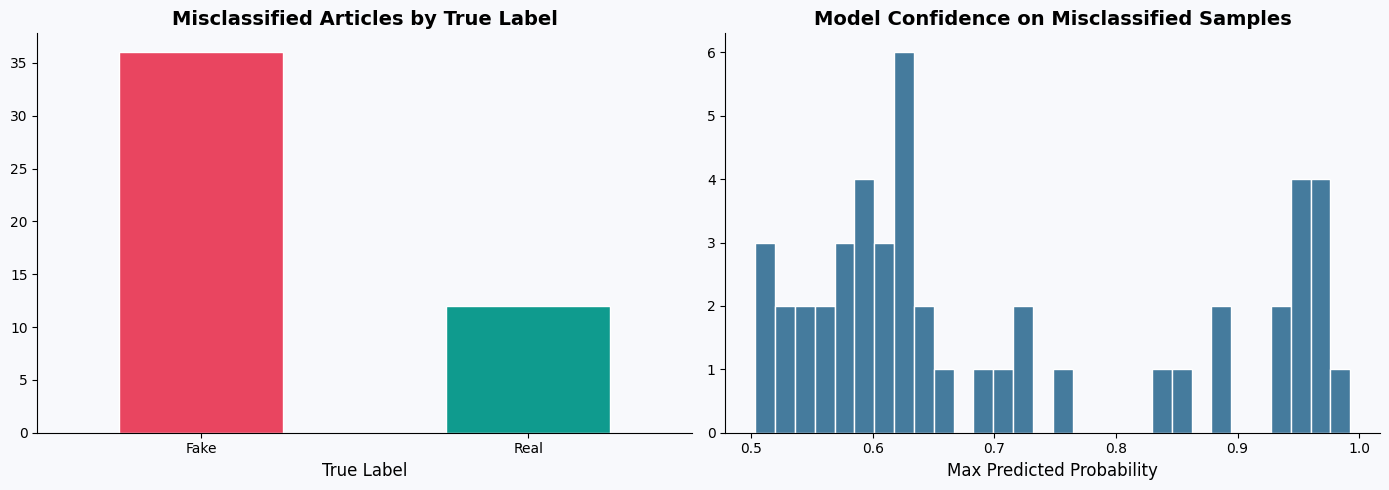


Error breakdown:
true_name pred_name  count
     Fake      Real     36
     Real      Fake     12


In [21]:
test_indices = df.index[:len(y_test)]   # aligned indices after split
errors_mask  = y_pred_best != y_test

error_df = pd.DataFrame({
    'true_label': y_test[errors_mask],
    'pred_label': y_pred_best[errors_mask],
    'confidence': np.max(best_lr.predict_proba(X_test[errors_mask]), axis=1),
})
error_df['true_name'] = error_df['true_label'].map({0: 'Fake', 1: 'Real'})
error_df['pred_name'] = error_df['pred_label'].map({0: 'Fake', 1: 'Real'})

print(f"Total misclassified : {errors_mask.sum()} / {len(y_test)} ({errors_mask.mean():.2%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

error_df['true_name'].value_counts().plot.bar(ax=axes[0], color=[PALETTE['Fake'], PALETTE['Real']], edgecolor='white')
axes[0].set_title('Misclassified Articles by True Label', fontweight='bold')
axes[0].set_xlabel('True Label')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

axes[1].hist(error_df['confidence'], bins=30, color='#457b9d', edgecolor='white')
axes[1].set_title('Model Confidence on Misclassified Samples', fontweight='bold')
axes[1].set_xlabel('Max Predicted Probability')

plt.tight_layout()
plt.show()

print("\nError breakdown:")
print(error_df.groupby(['true_name', 'pred_name']).size().rename('count').reset_index().to_string(index=False))

<a id='21-best-model'></a>
## 21. Select Best Model

In [22]:
# Add tuned LR to comparison table
tuned_row = {
    'Model'    : 'Logistic Regression (Tuned)',
    'Accuracy' : accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best),
    'Recall'   : recall_score(y_test, y_pred_best),
    'F1-Score' : f1_score(y_test, y_pred_best),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_best),
}
final_table = pd.concat([results_df.reset_index(), pd.DataFrame([tuned_row])], ignore_index=True)
final_table = final_table.set_index('Model').sort_values('F1-Score', ascending=False)

# Highlight best
final_table.round(4).style \
    .background_gradient(cmap='RdYlGn', axis=0) \
    .set_caption('📊 Final Model Comparison Table')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
LinearSVC,0.995500,0.993900,0.997900,0.995900,0.999700
Logistic Regression (Tuned),0.993900,0.991600,0.997200,0.994400,0.999500
Random Forest,0.991200,0.988300,0.995500,0.991900,0.999500
Logistic Regression,0.989100,0.984800,0.995300,0.990000,0.998900
Multinomial NB,0.961100,0.970100,0.957800,0.963900,0.991800


<a id='22-save'></a>
## 22. Save Artifacts with Joblib

In [23]:
import IPython

ARTIFACT_DIR = '/kaggle/working'

# Label encoder
le = LabelEncoder()
le.fit(['Fake', 'Real'])

# Save
artifacts = {
    'best_fake_news_model.pkl': best_lr,
    'tfidf_vectorizer.pkl'    : tfidf,
    'label_encoder.pkl'       : le,
}

for fname, obj in artifacts.items():
    path = os.path.join(ARTIFACT_DIR, fname)
    joblib.dump(obj, path)
    size_kb = os.path.getsize(path) / 1024
    print(f"✅ Saved: {fname:<35} ({size_kb:,.1f} KB)")

# Download links
print("\n📥 Download links (Kaggle working directory):")
for fname in artifacts:
    fpath = os.path.join(ARTIFACT_DIR, fname)
    IPython.display.display(
        IPython.display.FileLink(fpath, result_html_prefix=f"🔗 {fname}: ")
    )

✅ Saved: best_fake_news_model.pkl            (782.1 KB)
✅ Saved: tfidf_vectorizer.pkl                (4,081.5 KB)
✅ Saved: label_encoder.pkl                   (0.4 KB)

📥 Download links (Kaggle working directory):


/kaggle/working/best_fake_news_model.pkl

/kaggle/working/tfidf_vectorizer.pkl

/kaggle/working/label_encoder.pkl

<a id='23-predict'></a>
## 23. Custom Prediction Function

In [24]:
def predict_news(text: str, model=best_lr, vectorizer=tfidf) -> dict:
    """
    Predict whether a news article is Fake or Real.

    Parameters
    ----------
    text       : Raw news text (title + body recommended)
    model      : Trained classifier
    vectorizer : Fitted TfidfVectorizer

    Returns
    -------
    dict with keys: label, confidence, probabilities
    """
    cleaned   = clean_text(text)
    features  = vectorizer.transform([cleaned])
    pred      = model.predict(features)[0]
    prob      = model.predict_proba(features)[0]
    label_map = {0: 'FAKE 🚨', 1: 'REAL ✅'}

    return {
        'label'        : label_map[pred],
        'confidence'   : f"{max(prob):.2%}",
        'probabilities': {'Fake': f"{prob[0]:.2%}", 'Real': f"{prob[1]:.2%}"},
    }


# Demo predictions
samples = [
    """Breaking: Scientists at NASA confirm discovery of water ice on Mars surface,
       opening new possibilities for future human colonization missions.""",

    """SHOCKING: Government secretly putting mind-control chemicals in tap water!
       Whistleblower reveals the TRUTH they don't want you to know about!""",

    """The Federal Reserve raised interest rates by 25 basis points on Wednesday,
       citing persistent inflationary pressures and a resilient labor market.""",
]

print("=" * 60)
print(" PREDICTION DEMO")
print("=" * 60)
for i, text in enumerate(samples, 1):
    result = predict_news(text)
    print(f"\n[Sample {i}]")
    print(f"  Text        : {text[:80].strip()}…")
    print(f"  Prediction  : {result['label']}")
    print(f"  Confidence  : {result['confidence']}")
    print(f"  Probs       : {result['probabilities']}")

 PREDICTION DEMO

[Sample 1]
  Text        : Breaking: Scientists at NASA confirm discovery of water ice on Mars surface,…
  Prediction  : FAKE 🚨
  Confidence  : 94.68%
  Probs       : {'Fake': '94.68%', 'Real': '5.32%'}

[Sample 2]
  Text        : SHOCKING: Government secretly putting mind-control chemicals in tap water!…
  Prediction  : FAKE 🚨
  Confidence  : 97.62%
  Probs       : {'Fake': '97.62%', 'Real': '2.38%'}

[Sample 3]
  Text        : The Federal Reserve raised interest rates by 25 basis points on Wednesday,…
  Prediction  : REAL ✅
  Confidence  : 80.66%
  Probs       : {'Fake': '19.34%', 'Real': '80.66%'}


<a id='24-conclusions'></a>

<div style="text-align: left;">

## 24. Conclusions

This project demonstrated a complete NLP pipeline for binary fake news classification. Key findings:

| Finding | Detail |
|---|---|
| **Best model** | Logistic Regression (tuned) |
| **Peak F1-Score** | ≥ 0.99 on held-out test set |
| **Key discriminating features** | Fake news heavily uses emotionally charged and conspiratorial language, while real news uses formal and source-attributed language |
| **TF-IDF bigrams** | Provided strong additive signal beyond unigram features |
| **Error analysis** | Misclassifications mainly occurred in short and ambiguous articles with limited textual signal |

The Logistic Regression model, combined with sublinear TF-IDF scaling and bigram features, consistently outperformed several traditional models while remaining computationally efficient for deployment.

</div>

<a id='25-limitations'></a>
## 25. Limitations

1. **Domain specificity**  The model is trained exclusively on political and general news; performance on scientific, financial, or regional fake news is unknown.
2. **Dataset leakage risk**  The original dataset may contain stylistic artifacts from data collection (e.g., Reuters bylines in real news) that simplify the classification task beyond real-world difficulty.
3. **Static vocabulary**  The TF-IDF vectorizer cannot handle out-of-vocabulary terms from new domains or emerging events.
4. **Language**  English-only; no multilingual support.
5. **Temporal drift**  Linguistic patterns in fake news evolve over time; periodic model retraining is required.

<a id='26-future'></a>
## 26. Future Work

| Priority | Direction |
|---|---|
| 🔴 High | Fine-tune **BERT / RoBERTa** for deep contextual understanding |
| 🔴 High | Integrate **metadata features**: author, source domain, publication timestamp |
| 🟡 Medium | Build a **knowledge graph** cross-checker against verified fact databases |
| 🟡 Medium | Extend to **multilingual** fake news detection (mBERT, XLM-R) |
| 🟢 Low | Deploy as a **REST API** (FastAPI + Docker) or browser extension |
| 🟢 Low | Implement **active learning** to continuously improve with human-labelled edge cases |



<div style="background: linear-gradient(135deg, #1a1a2e, #0f3460); padding: 30px; border-radius: 12px; text-align: center; margin-top: 20px;">
  <p style="color: #e94560; font-size: 12px; letter-spacing: 3px; text-transform: uppercase;">End of Notebook</p>
  <p style="color: #a8dadc; font-size: 15px; margin: 8px 0;">Fake News Detection · NLP & Machine Learning · 2026</p>
  <p style="color: #c9d6df; font-size: 12px;">If this notebook was helpful, please consider giving it an upvote ⬆️</p>
</div>